# Plateau Decay Amount and Metrics Analysis

This notebook analyzes the plateau-region decay amount sweep.

Design:

- Stable training continues to step 1400.
- At several checkpoints, probes branch from the current model state.
- Each probe trains for 150 steps with a different final LR ratio.
- `final_lr_ratio = 1.0` is the stable-continuation baseline for that same checkpoint.

The key target is not raw final validation loss across checkpoints, because later checkpoints are expected to be better. The key target is:

```text
decay_advantage = val_after_decay_ratio - val_after_ratio_1.0
```

Negative values mean the decay ratio beats stable continuation from the same checkpoint.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

In [2]:
# Set RUN_NAME after the run finishes, or leave as None to use the latest matching run.
RUN_NAME = "wsd_intermediate_plateau_amount_sweep_5k_20260607-074756"
LOG_ROOT = Path("../logs")
PREFIX = "wsd_intermediate_plateau_amount_sweep_5k"

if RUN_NAME is None:
    candidates = sorted(p for p in LOG_ROOT.iterdir() if p.is_dir() and p.name.startswith(PREFIX) and (p / "decay_amount_sweep.jsonl").exists())
    if not candidates:
        raise FileNotFoundError(f"No completed {PREFIX} runs found under {LOG_ROOT}")
    LOG_DIR = candidates[-1]
else:
    LOG_DIR = LOG_ROOT / RUN_NAME

assert (LOG_DIR / "metrics.jsonl").exists(), "Missing metrics.jsonl"
assert (LOG_DIR / "decay_amount_sweep.jsonl").exists(), "Missing decay_amount_sweep.jsonl"
assert (LOG_DIR / "decay_amount_trajectory.jsonl").exists(), "Missing decay_amount_trajectory.jsonl"

def read_jsonl(path):
    with open(path) as f:
        return pd.DataFrame(json.loads(line) for line in f if line.strip())

metrics = read_jsonl(LOG_DIR / "metrics.jsonl")
sweep = read_jsonl(LOG_DIR / "decay_amount_sweep.jsonl")
trajectory = read_jsonl(LOG_DIR / "decay_amount_trajectory.jsonl")

val_rows = metrics[metrics["validation_loss"].notna()][["step", "validation_loss"]].rename(
    columns={"step": "probe_start_step", "validation_loss": "probe_start_val_loss"}
)
sweep = sweep.merge(val_rows, on="probe_start_step", how="left")
trajectory = trajectory.merge(val_rows, on="probe_start_step", how="left")
trajectory["global_step_equivalent"] = trajectory["probe_start_step"] + trajectory["probe_decay_step"]

baseline = sweep[sweep["final_lr_ratio"] == 1.0][["probe_start_step", "probe_final_val_loss"]].rename(
    columns={"probe_final_val_loss": "stable_continuation_val_loss"}
)
sweep = sweep.merge(baseline, on="probe_start_step", how="left")
sweep["decay_advantage"] = sweep["probe_final_val_loss"] - sweep["stable_continuation_val_loss"]
sweep["decay_val_improvement"] = sweep["probe_start_val_loss"] - sweep["probe_final_val_loss"]
sweep["log_final_lr_ratio"] = np.log10(sweep["final_lr_ratio"])
sweep["lr_drop_fraction"] = 1 - sweep["final_lr_ratio"]

traj_base = trajectory[trajectory["final_lr_ratio"] == 1.0][["probe_start_step", "probe_decay_step", "probe_validation_loss"]].rename(
    columns={"probe_validation_loss": "stable_continuation_validation_loss"}
)
trajectory = trajectory.merge(traj_base, on=["probe_start_step", "probe_decay_step"], how="left")
trajectory["decay_advantage"] = trajectory["probe_validation_loss"] - trajectory["stable_continuation_validation_loss"]

print(f"Run: {LOG_DIR.name}")
print(f"metrics rows: {len(metrics)}")
print(f"sweep rows: {len(sweep)}")
print(f"trajectory rows: {len(trajectory)}")
print(f"starts: {sorted(sweep['probe_start_step'].unique())}")
print(f"ratios: {sorted(sweep['final_lr_ratio'].unique(), reverse=True)}")

Run: wsd_intermediate_plateau_amount_sweep_5k_20260607-074756
metrics rows: 1100
sweep rows: 30
trajectory rows: 300
starts: [np.int64(2500), np.int64(3000), np.int64(3500), np.int64(4000), np.int64(4500)]
ratios: [np.float64(1.0), np.float64(0.5), np.float64(0.3), np.float64(0.2), np.float64(0.1), np.float64(0.03)]


## Stable Training Curve and Probe Starts

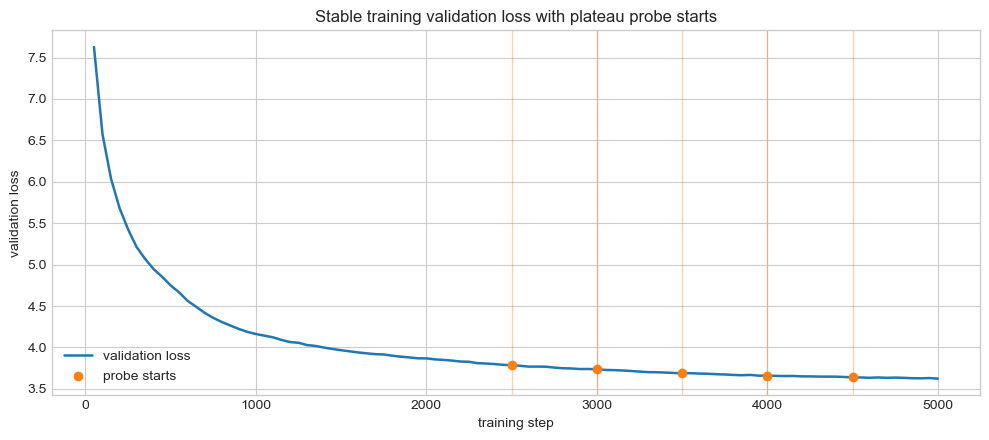

In [3]:
train_rows = metrics[metrics["train_loss"].notna()].copy()
val_curve = metrics[metrics["validation_loss"].notna()].copy()
starts = sorted(sweep["probe_start_step"].unique())

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(val_curve["step"], val_curve["validation_loss"], color="tab:blue", linewidth=1.8, label="validation loss")
for step in starts:
    ax.axvline(step, color="tab:orange", alpha=0.35, linewidth=1)
ax.scatter(starts, val_rows[val_rows["probe_start_step"].isin(starts)]["probe_start_val_loss"], color="tab:orange", zorder=4, label="probe starts")
ax.set_xlabel("training step")
ax.set_ylabel("validation loss")
ax.set_title("Stable training validation loss with plateau probe starts")
ax.legend()
plt.tight_layout()
plt.show()

## Online Metrics Overview

This grid gives a quick sanity check of the online metrics recorded during stable training. Vertical dashed lines mark the probe start steps used in the decay amount sweep.


In [ ]:
overview_metrics = [
    ("train_loss", "Train loss", "steelblue"),
    ("loss_variance", "Loss variance", "steelblue"),
    ("loss_oscillation", "Loss oscillation", "steelblue"),
    ("loss_improvement_rate", "Loss improvement rate", "steelblue"),
    ("grad_norm", "Gradient norm", "darkorange"),
    ("grad_snr", "Gradient SNR", "darkorange"),
    ("grad_weight_ratio", "Grad/weight ratio", "darkorange"),
    ("grad_cosine_sim", "Grad cosine sim", "darkorange"),
    ("weight_norm", "Weight norm", "seagreen"),
    ("param_update_norm", "Param update norm", "seagreen"),
    ("adam_v_norm", "Adam v norm", "seagreen"),
    ("learning_rate", "Learning rate", "purple"),
]

ncols = 4
nrows = (len(overview_metrics) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.2))
axes = axes.flatten()

for ax, (col, label, color) in zip(axes, overview_metrics):
    if col not in train_rows.columns:
        ax.set_visible(False)
        continue
    ax.plot(train_rows["step"], train_rows[col], color=color, linewidth=1.0)
    for step in starts:
        ax.axvline(step, color="gray", linestyle="--", linewidth=0.7, alpha=0.35)
    if col == "grad_cosine_sim" or col == "loss_improvement_rate":
        ax.axhline(0, color="red", linestyle=":", linewidth=0.8, alpha=0.7)
    ax.set_title(label)
    ax.set_xlabel("Step")
    ax.grid(True, alpha=0.3)

for ax in axes[len(overview_metrics):]:
    ax.set_visible(False)

plt.suptitle("Online metrics during stable training", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Raw Final Validation Loss

This plot is useful descriptively, but do not use it alone to compare different start checkpoints. Later starts have more training.

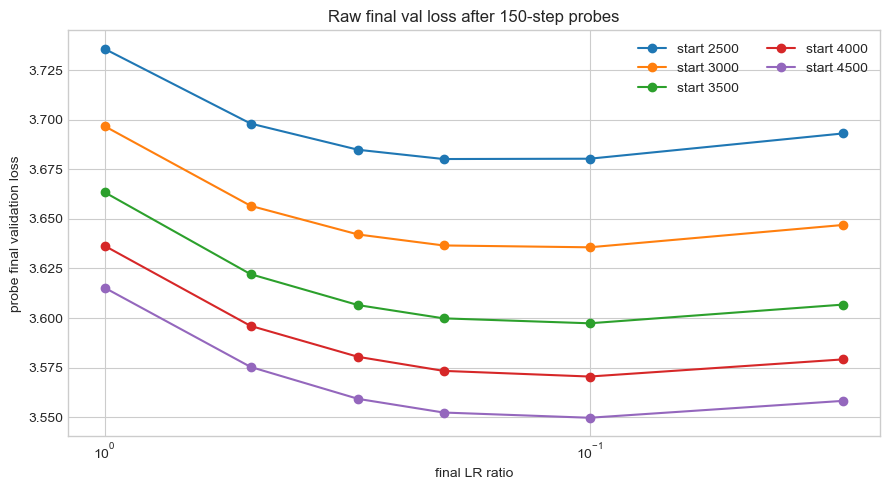

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for step, group in sweep.groupby("probe_start_step"):
    group = group.sort_values("final_lr_ratio", ascending=False)
    ax.plot(group["final_lr_ratio"], group["probe_final_val_loss"], marker="o", label=f"start {step}")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("final LR ratio")
ax.set_ylabel("probe final validation loss")
ax.set_title("Raw final val loss after 150-step probes")
ax.legend(ncols=2)
plt.tight_layout()
plt.show()

## Decay Advantage vs Stable Continuation

This is the central analysis. Negative values mean the decay amount beats `final_lr_ratio = 1.0` from the same checkpoint over the same 150-step horizon.

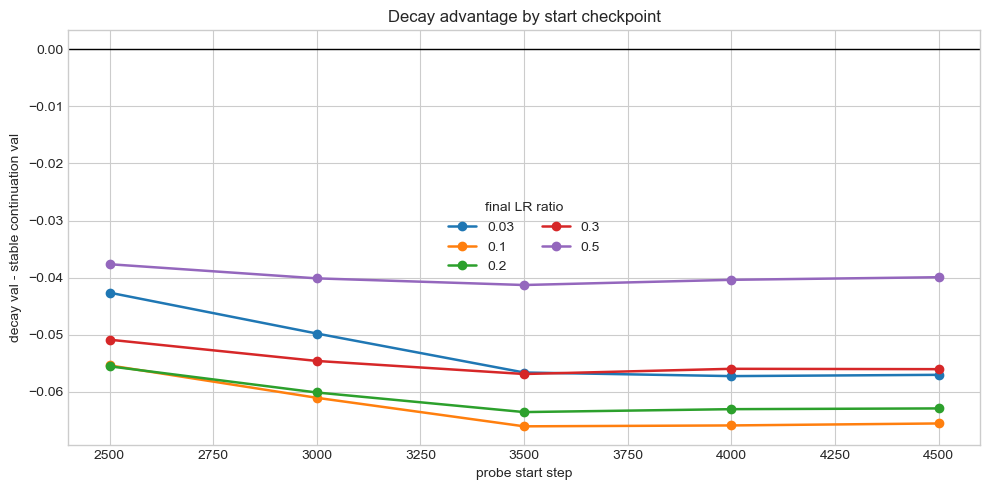

,probe_start_step,final_lr_ratio,probe_final_val_loss,stable_continuation_val_loss,decay_advantage
3,2500,0.200000,3.680170,3.735707,-0.055537
4,2500,0.100000,3.680331,3.735707,-0.055376
2,2500,0.300000,3.684832,3.735707,-0.050875
5,2500,0.030000,3.693071,3.735707,-0.042636
1,2500,0.500000,3.698053,3.735707,-0.037654
10,3000,0.100000,3.635678,3.696731,-0.061053
9,3000,0.200000,3.636608,3.696731,-0.060124
8,3000,0.300000,3.642134,3.696731,-0.054597
11,3000,0.030000,3.646938,3.696731,-0.049793
7,3000,0.500000,3.656601,3.696731,-0.040130


In [5]:
adv = sweep[sweep["final_lr_ratio"] != 1.0].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for ratio, group in adv.groupby("final_lr_ratio"):
    group = group.sort_values("probe_start_step")
    ax.plot(group["probe_start_step"], group["decay_advantage"], marker="o", linewidth=1.8, label=f"{ratio:g}")
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("probe start step")
ax.set_ylabel("decay val - stable continuation val")
ax.set_title("Decay advantage by start checkpoint")
ax.legend(title="final LR ratio", ncols=2)
plt.tight_layout()
plt.show()

adv[["probe_start_step", "final_lr_ratio", "probe_final_val_loss", "stable_continuation_val_loss", "decay_advantage"]].sort_values(["probe_start_step", "decay_advantage"])

## Best Ratio Per Checkpoint

In [6]:
best_by_start = sweep.loc[sweep.groupby("probe_start_step")["probe_final_val_loss"].idxmin()].copy()
best_by_start = best_by_start[[
    "probe_start_step", "probe_start_val_loss", "final_lr_ratio", "probe_final_val_loss",
    "stable_continuation_val_loss", "decay_advantage", "grad_snr", "grad_weight_ratio",
    "param_update_norm", "loss_improvement_rate"
]].sort_values("probe_start_step")
best_by_start

,probe_start_step,probe_start_val_loss,final_lr_ratio,probe_final_val_loss,stable_continuation_val_loss,decay_advantage,grad_snr,grad_weight_ratio,param_update_norm,loss_improvement_rate
3,2500,3.784918,0.200000,3.680170,3.735707,-0.055537,1.071511,0.000842,1.116744,-0.001576
10,3000,3.736492,0.100000,3.635678,3.696731,-0.061053,0.992386,0.001051,1.122200,0.005238
16,3500,3.688230,0.100000,3.597371,3.663421,-0.066050,1.042342,0.000865,1.114721,0.003397
22,4000,3.660025,0.100000,3.570538,3.636433,-0.065895,0.968254,0.000790,1.118269,-0.003277
28,4500,3.637486,0.100000,3.549756,3.615303,-0.065548,0.991030,0.000709,1.127141,-0.005091


## Validation Trajectories During Probes

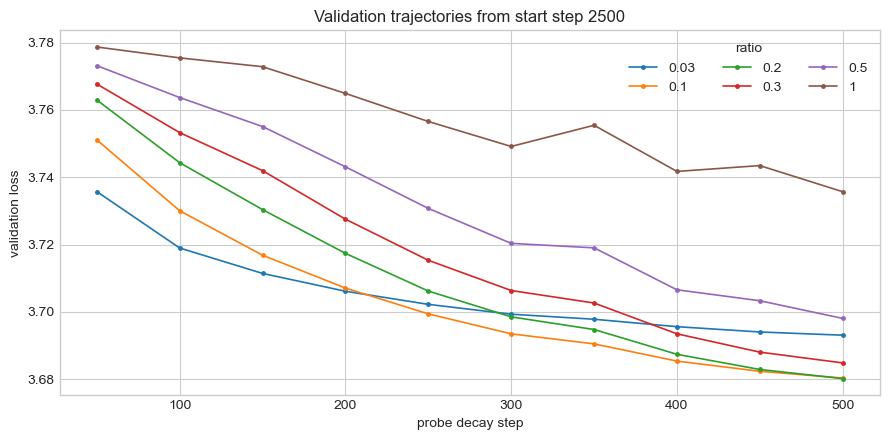

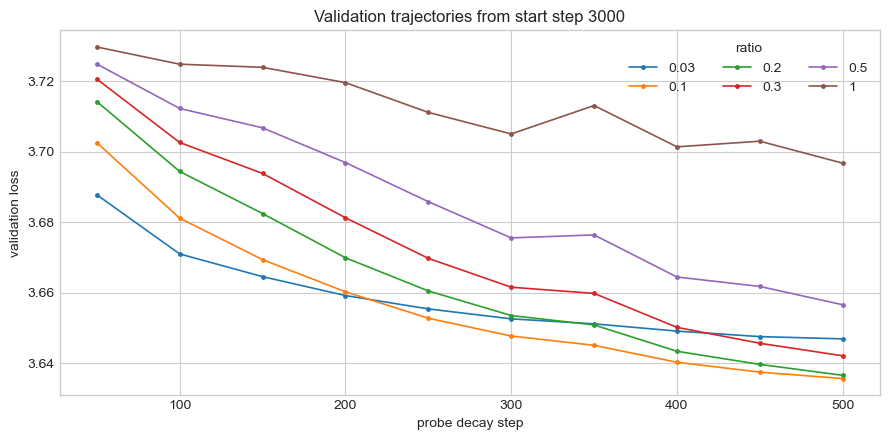

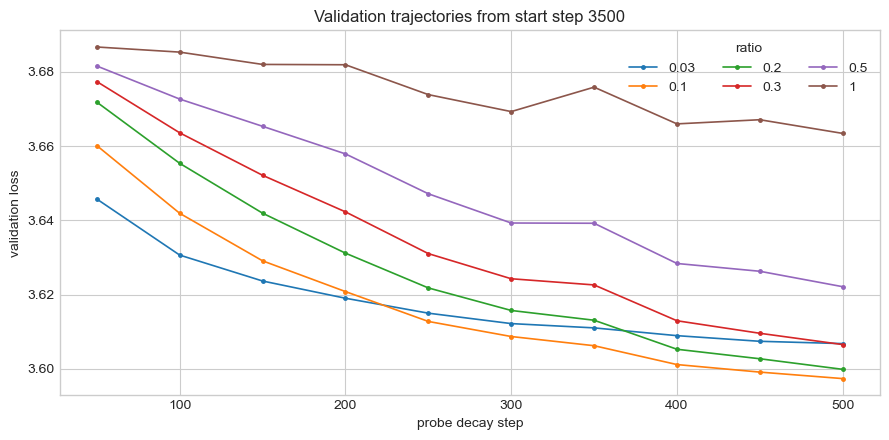

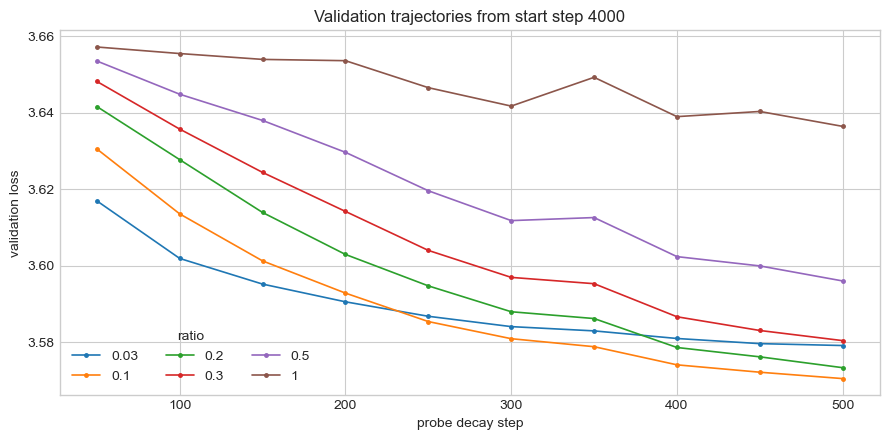

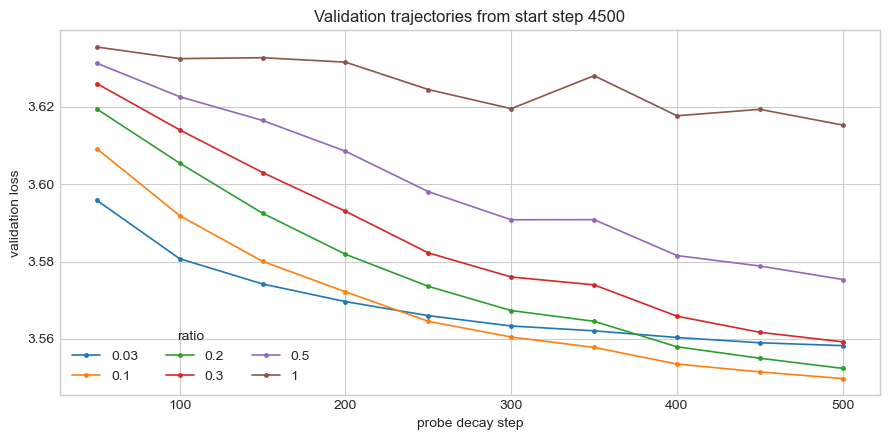

In [7]:
for step, step_df in trajectory.groupby("probe_start_step"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for ratio, group in step_df.groupby("final_lr_ratio"):
        group = group.sort_values("probe_decay_step")
        ax.plot(group["probe_decay_step"], group["probe_validation_loss"], marker="o", markersize=2.5, linewidth=1.2, label=f"{ratio:g}")
    ax.set_xlabel("probe decay step")
    ax.set_ylabel("validation loss")
    ax.set_title(f"Validation trajectories from start step {step}")
    ax.legend(title="ratio", ncols=3)
    plt.tight_layout()
    plt.show()

## Metric Links

These correlations ask whether metrics at the probe start predict decay advantage. Negative correlation means larger metric values are associated with more benefit from decay relative to stable continuation.

In [8]:
metric_cols = [
    "probe_start_val_loss", "loss_variance", "loss_oscillation", "loss_improvement_rate",
    "grad_norm", "grad_snr", "grad_weight_ratio", "grad_cosine_sim",
    "adam_v_norm", "weight_norm", "param_update_norm",
]

rows = []
for ratio, group in adv.groupby("final_lr_ratio"):
    y = group["decay_advantage"].to_numpy()
    for metric in metric_cols:
        if metric not in group:
            continue
        x = group[metric].to_numpy()
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 3 or np.allclose(x[mask], x[mask][0]) or np.allclose(y[mask], y[mask][0]):
            continue
        pearson_r, pearson_p = stats.pearsonr(x[mask], y[mask])
        spearman_r, spearman_p = stats.spearmanr(x[mask], y[mask])
        rows.append({
            "final_lr_ratio": ratio,
            "metric": metric,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p": spearman_p,
        })
metric_corr = pd.DataFrame(rows).sort_values(["final_lr_ratio", "pearson_r"])
metric_corr

,final_lr_ratio,metric,pearson_r,pearson_p,spearman_r,spearman_p
9,0.030000,weight_norm,-0.919129,0.027270,-0.900000,0.037386
8,0.030000,adam_v_norm,-0.871176,0.054420,-0.700000,0.188120
7,0.030000,grad_cosine_sim,-0.390561,0.515670,-0.600000,0.284757
10,0.030000,param_update_norm,-0.226800,0.713724,-0.300000,0.623838
1,0.030000,loss_variance,-0.141708,0.820178,0.300000,0.623838
4,0.030000,grad_norm,0.192606,0.756291,0.200000,0.747060
3,0.030000,loss_improvement_rate,0.203713,0.742430,0.600000,0.284757
6,0.030000,grad_weight_ratio,0.409505,0.493565,0.600000,0.284757
5,0.030000,grad_snr,0.654933,0.230315,0.900000,0.037386
2,0.030000,loss_oscillation,0.942936,0.016223,1.000000,0.000000


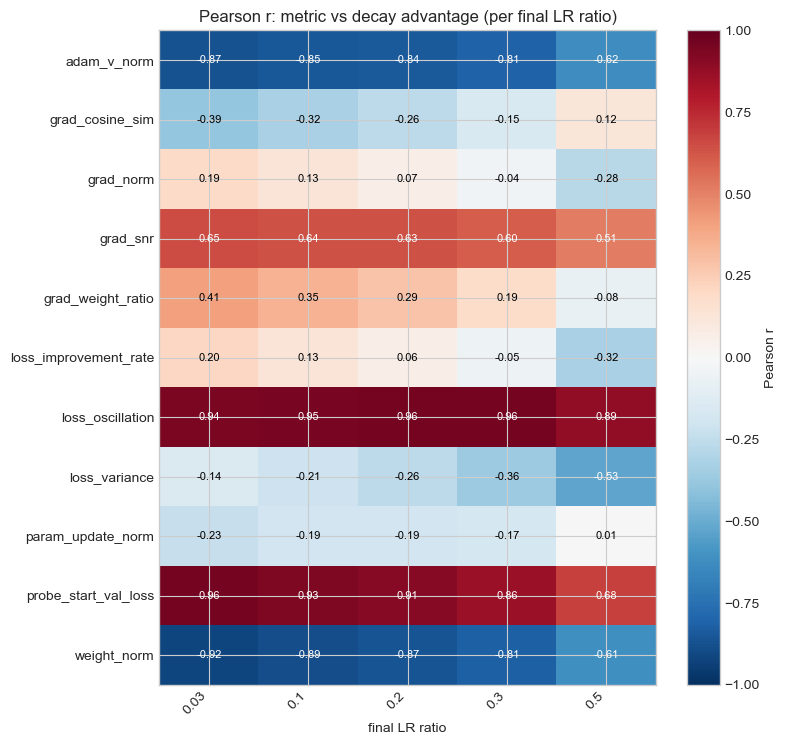

In [9]:
if not metric_corr.empty:
    pivot = metric_corr.pivot(index="metric", columns="final_lr_ratio", values="pearson_r")

    # --- Heatmap ---
    fig, ax = plt.subplots(figsize=(len(pivot.columns) * 1.2 + 2, len(pivot) * 0.55 + 1.5))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, label="Pearson r")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{c:g}" for c in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                        color="white" if abs(val) > 0.5 else "black")
    ax.set_title("Pearson r: metric vs decay advantage (per final LR ratio)", fontsize=12)
    ax.set_xlabel("final LR ratio")
    plt.tight_layout()
    plt.show()

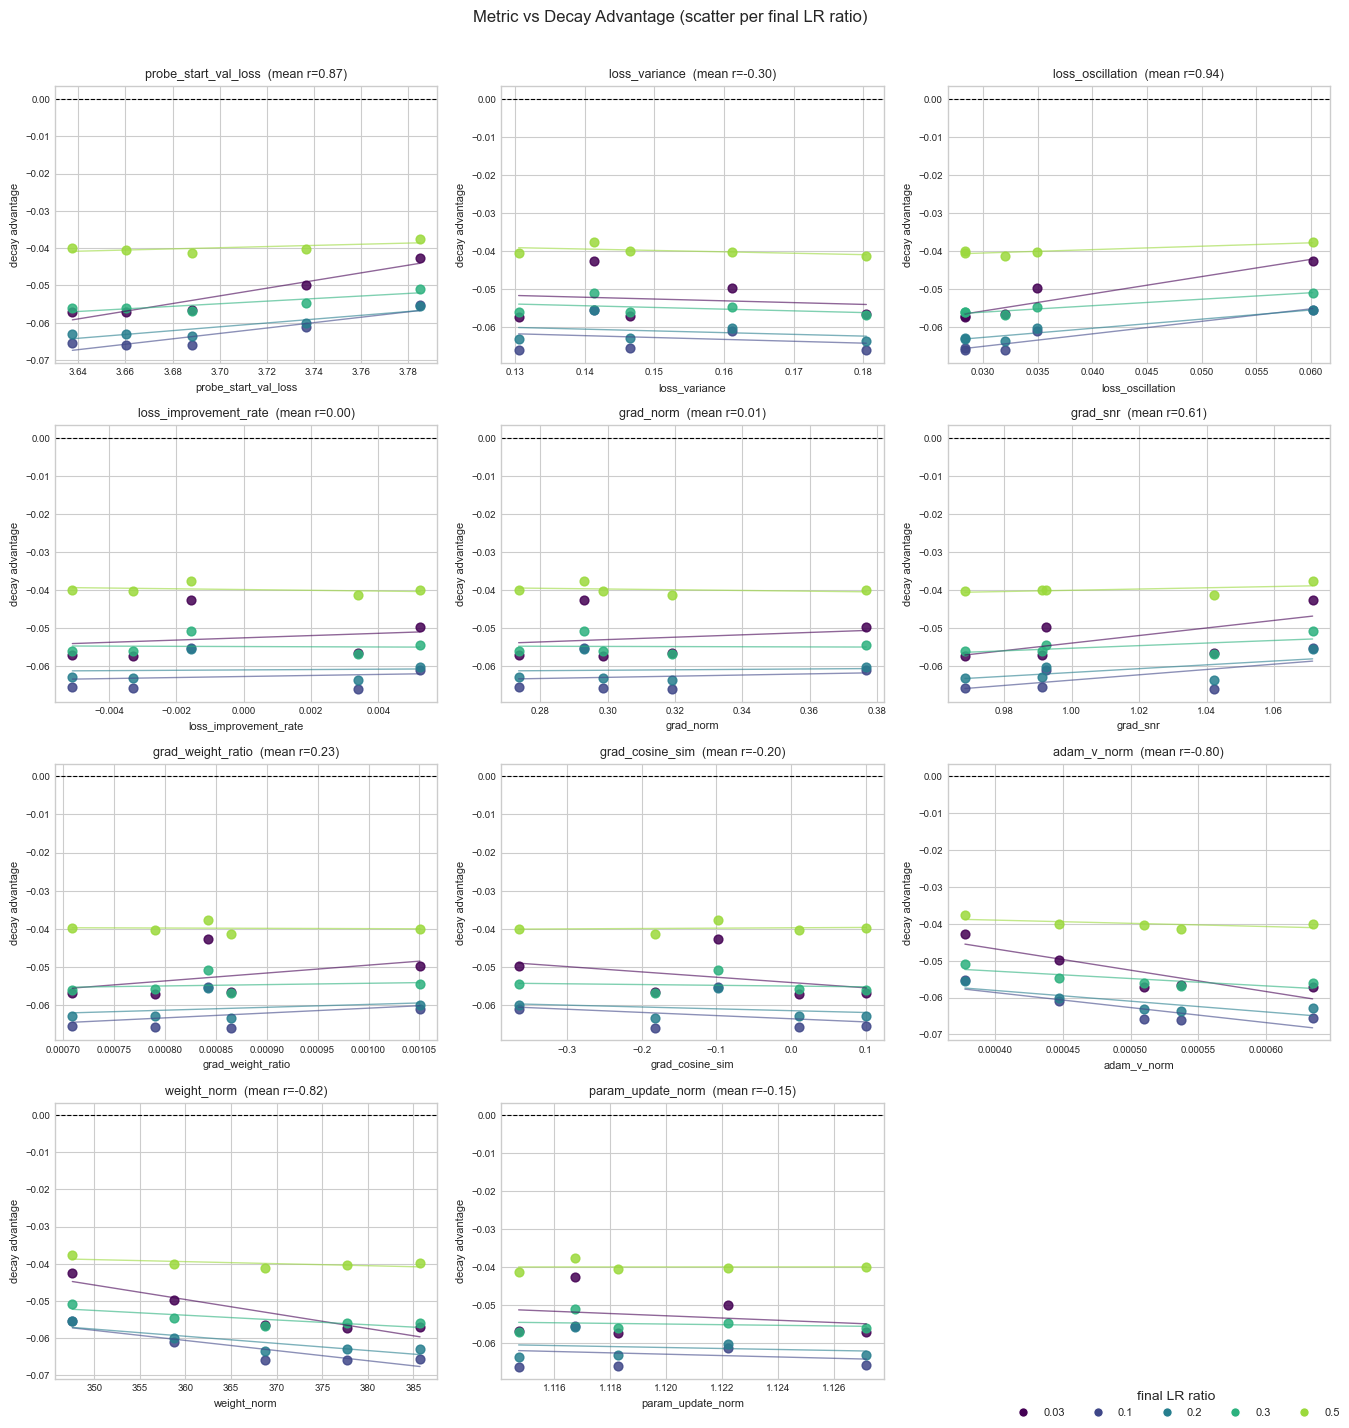

In [10]:
# --- Scatter plots: each metric vs decay_advantage, one subplot per metric ---
if not metric_corr.empty:
    ratios = sorted(adv["final_lr_ratio"].unique())
    colors = plt.cm.viridis(np.linspace(0, 0.85, len(ratios)))
    ratio_color = dict(zip(ratios, colors))

    ncols = 3
    nrows = -(-len(metric_cols) // ncols)  # ceil division
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.5))
    axes = axes.flatten()

    for idx, metric in enumerate(metric_cols):
        ax = axes[idx]
        if metric not in adv.columns:
            ax.set_visible(False)
            continue
        for ratio, color in ratio_color.items():
            group = adv[adv["final_lr_ratio"] == ratio].dropna(subset=[metric, "decay_advantage"])
            ax.scatter(group[metric], group["decay_advantage"], color=color, label=f"{ratio:g}", s=40, alpha=0.85)
            if len(group) >= 2:
                m, b = np.polyfit(group[metric], group["decay_advantage"], 1)
                xs = np.array([group[metric].min(), group[metric].max()])
                ax.plot(xs, m * xs + b, color=color, linewidth=1, alpha=0.6)
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_xlabel(metric, fontsize=8)
        ax.set_ylabel("decay advantage", fontsize=8)
        ax.tick_params(labelsize=7)
        r_vals = metric_corr[metric_corr["metric"] == metric].set_index("final_lr_ratio")["pearson_r"]
        mean_r = r_vals.mean() if not r_vals.empty else float("nan")
        ax.set_title(f"{metric}  (mean r={mean_r:.2f})", fontsize=9)

    for idx in range(len(metric_cols), len(axes)):
        axes[idx].set_visible(False)

    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=ratio_color[r], markersize=7, label=f"{r:g}") for r in ratios]
    fig.legend(handles=handles, title="final LR ratio", loc="lower right", ncols=len(ratios), fontsize=8)
    fig.suptitle("Metric vs Decay Advantage (scatter per final LR ratio)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

## Interpretation Checklist

Look for:

- Does any ratio have negative decay advantage after step 1000?
- Does the best ratio shift from `1.0` or `0.5` toward `0.3/0.2/0.1` as the plateau develops?
- Do `grad_snr`, `grad_weight_ratio`, or `loss_improvement_rate` correlate with decay advantage?
- If no decay ratio beats `1.0`, the conclusion is that the model still benefits more from stable LR continuation than decay in this window.

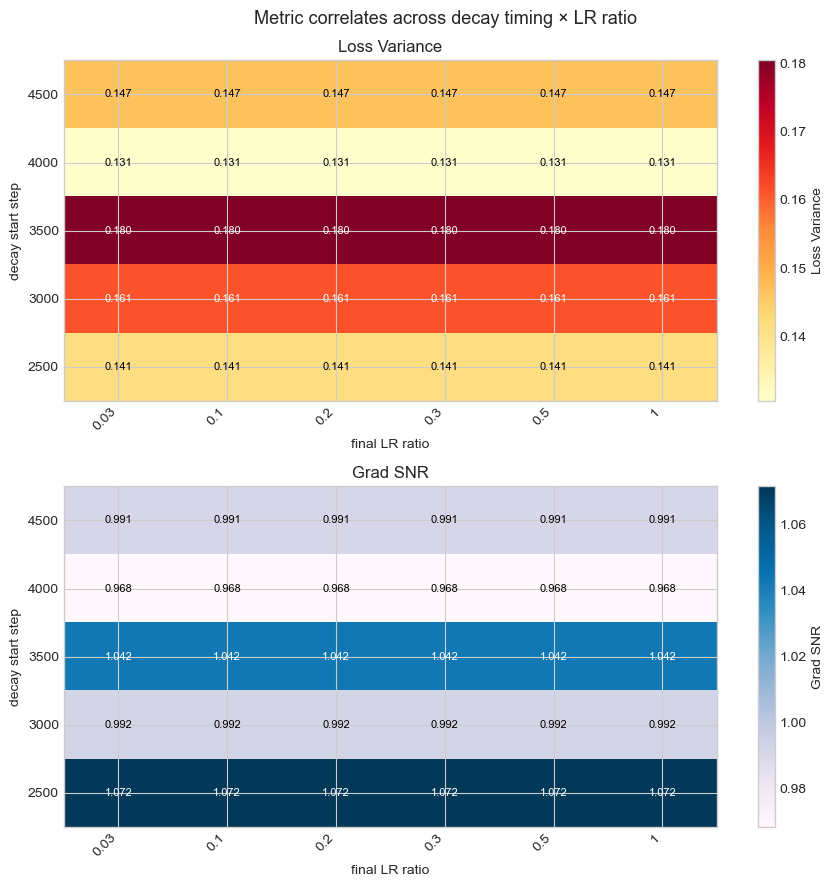

In [11]:
# Heatmap: loss_variance and grad_snr across (probe_start_step × final_lr_ratio)
_metrics = ["loss_variance", "grad_snr"]
_labels  = ["Loss Variance", "Grad SNR"]
_cmaps   = ["YlOrRd", "PuBu"]

fig, axes = plt.subplots(2, 1, figsize=(9, 9))

for ax, metric, label, cmap in zip(axes, _metrics, _labels, _cmaps):
    if metric not in sweep.columns:
        ax.set_visible(False)
        continue
    pivot = sweep.pivot(index="probe_start_step", columns="final_lr_ratio", values=metric)
    pivot = pivot.sort_index(ascending=False)  # later starts at top

    vmin, vmax = np.nanmin(pivot.values), np.nanmax(pivot.values)
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label=label)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{c:g}" for c in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(s) for s in pivot.index])
    ax.set_xlabel("final LR ratio")
    ax.set_ylabel("decay start step")
    ax.set_title(label, fontsize=12)

    mid = (vmin + vmax) / 2
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8,
                        color="white" if val > mid else "black")

fig.suptitle("Metric correlates across decay timing × LR ratio", fontsize=13)
plt.tight_layout()
plt.show()

## Decay Advantage vs Metrics — Multi-View

**Decay advantage** is defined as:

```
decay_advantage = probe_final_val_loss − stable_continuation_val_loss
```

Both quantities are measured after the same 150-step horizon from the same checkpoint.  
- **Negative** → the LR decay beats keeping the LR flat (decay helped).  
- **Zero** → no difference.  
- **Positive** → stable continuation was better.

The plots below explore how `decay_advantage` jointly depends on the **final LR ratio**, the **decay start step**, and the checkpoint-level metrics **loss variance** and **grad SNR**.

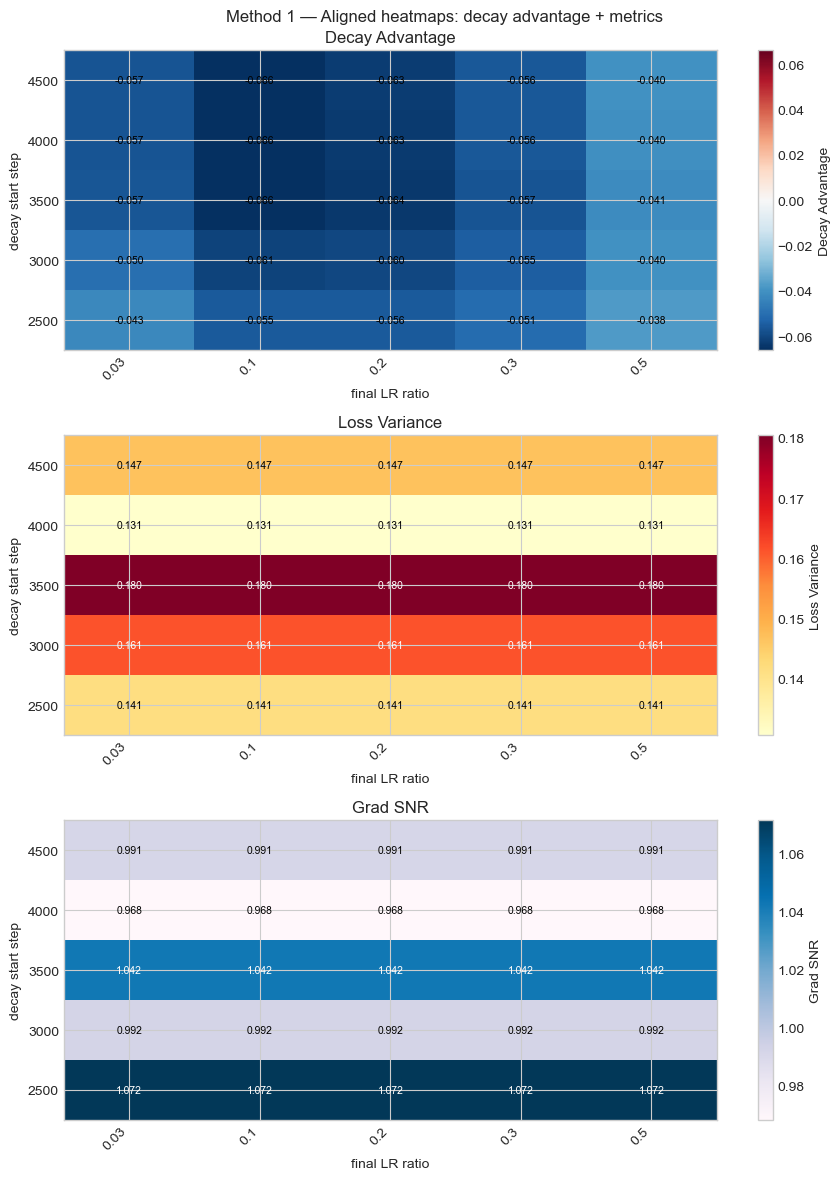

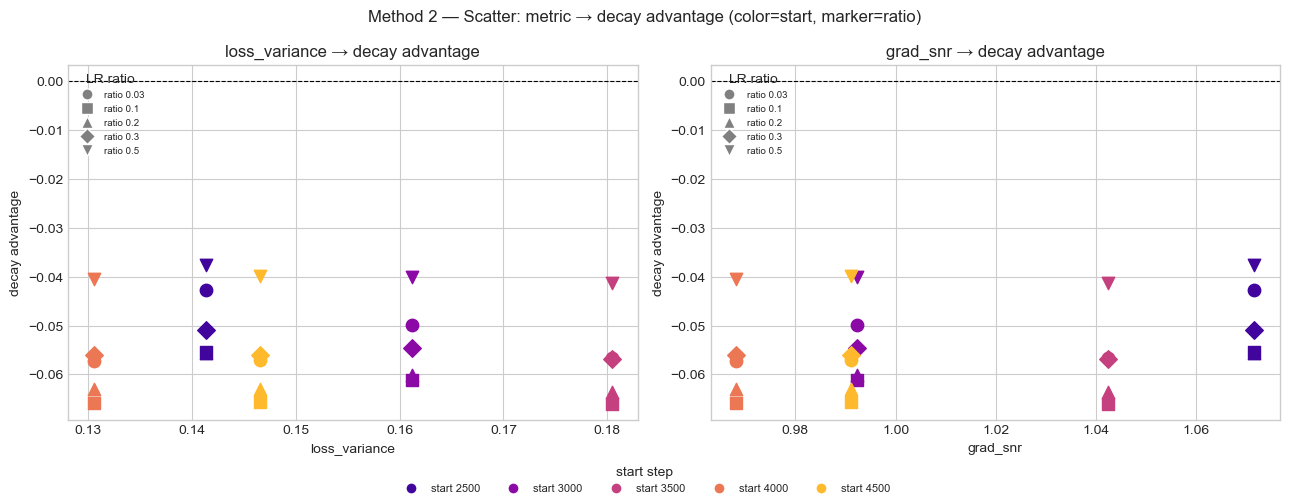

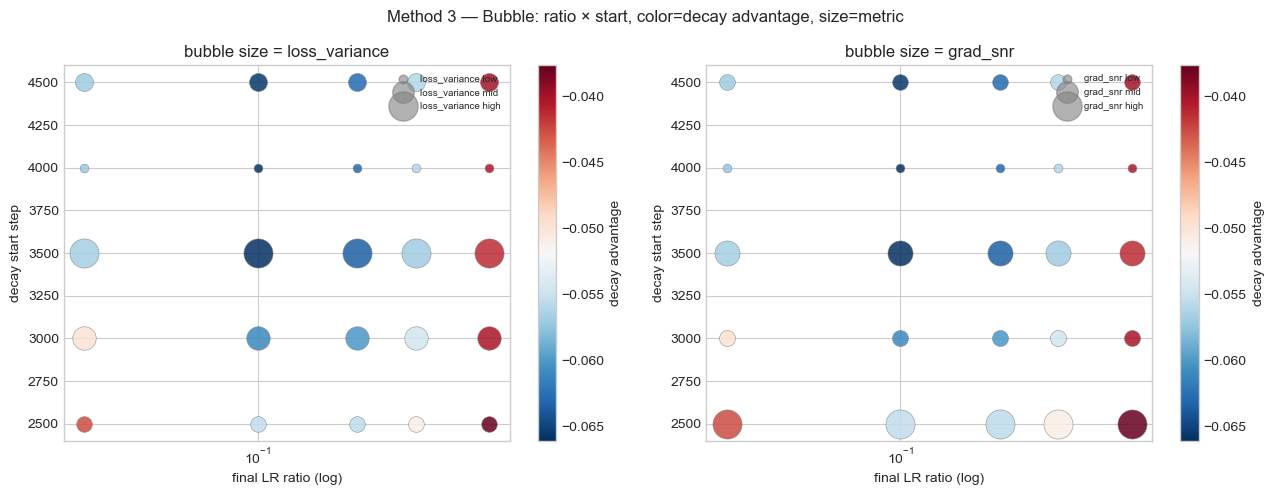

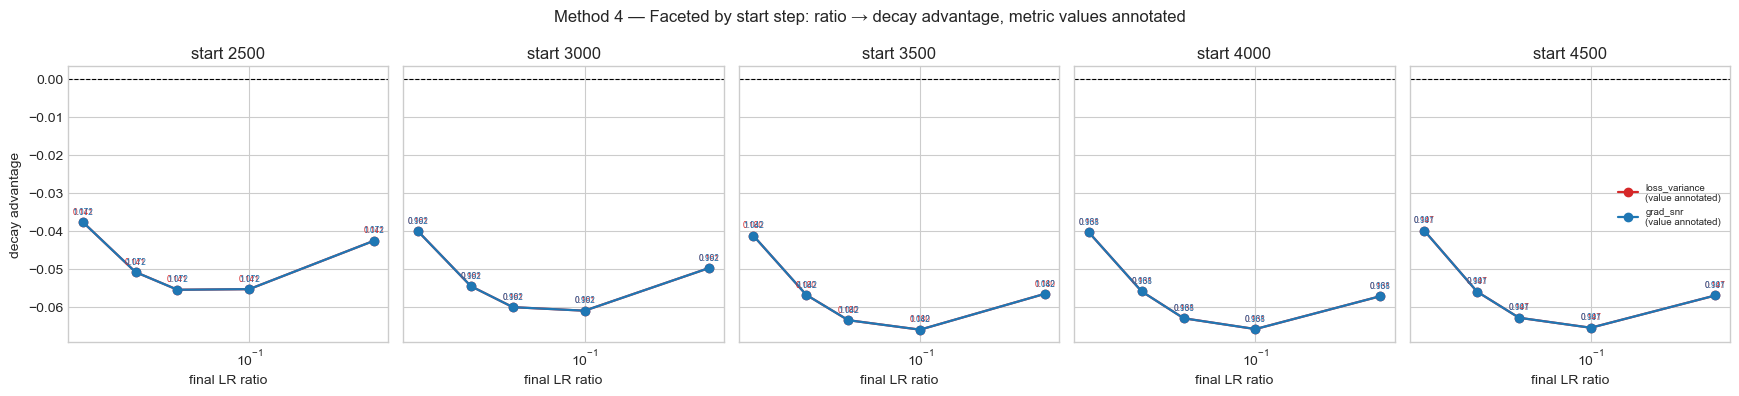

In [12]:
_adv = sweep[sweep["final_lr_ratio"] != 1.0].copy()
_starts  = sorted(_adv["probe_start_step"].unique())
_ratios  = sorted(_adv["final_lr_ratio"].unique())
_metrics = ["loss_variance", "grad_snr"]
_start_colors = dict(zip(_starts, plt.cm.plasma(np.linspace(0.1, 0.85, len(_starts)))))
_ratio_markers = dict(zip(_ratios, ["o", "s", "^", "D", "v"]))

# ── Method 1: three aligned heatmaps ────────────────────────────────────────
# decay_advantage / loss_variance / grad_snr on the same start×ratio grid.
# Good for spotting spatial co-occurrence between metric patterns and where decay helps.

fig, axes = plt.subplots(3, 1, figsize=(9, 12))
_hmap_specs = [
    ("decay_advantage", "Decay Advantage",  "RdBu_r",  True),
    ("loss_variance",   "Loss Variance",    "YlOrRd",  False),
    ("grad_snr",        "Grad SNR",         "PuBu",    False),
]
for ax, (col, title, cmap, diverge) in zip(axes, _hmap_specs):
    piv = _adv.pivot(index="probe_start_step", columns="final_lr_ratio", values=col).sort_index(ascending=False)
    vmin, vmax = np.nanmin(piv.values), np.nanmax(piv.values)
    kwargs = dict(vmin=-max(abs(vmin), abs(vmax)), vmax=max(abs(vmin), abs(vmax))) if diverge else dict(vmin=vmin, vmax=vmax)
    im = ax.imshow(piv.values, aspect="auto", cmap=cmap, **kwargs)
    plt.colorbar(im, ax=ax, label=title)
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f"{c:g}" for c in piv.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(piv.index)));  ax.set_yticklabels([str(s) for s in piv.index])
    ax.set_xlabel("final LR ratio"); ax.set_ylabel("decay start step"); ax.set_title(title)
    mid = (kwargs.get("vmin", vmin) + kwargs.get("vmax", vmax)) / 2
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7.5,
                        color="white" if v > mid else "black")
fig.suptitle("Method 1 — Aligned heatmaps: decay advantage + metrics", fontsize=12)
plt.tight_layout(); plt.show()

# ── Method 2: scatter — metric value → decay advantage ──────────────────────
# Each point is one (start_step, ratio) pair.
# Color = final LR ratio, marker = start step.
# Reveals whether high loss variance / grad SNR predicts larger decay benefit.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, _metrics):
    for ratio in _ratios:
        for start in _starts:
            row = _adv[(_adv["final_lr_ratio"] == ratio) & (_adv["probe_start_step"] == start)]
            if row.empty or metric not in row.columns: continue
            ax.scatter(row[metric].values[0], row["decay_advantage"].values[0],
                       color=_start_colors[start], marker=_ratio_markers[ratio], s=80, zorder=3)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel(metric); ax.set_ylabel("decay advantage"); ax.set_title(f"{metric} → decay advantage")
    # legends
    ax.legend(
        [plt.Line2D([0],[0], marker=_ratio_markers[r], color="w", markerfacecolor="grey", markersize=8, label=f"ratio {r:g}") for r in _ratios],
        [f"ratio {r:g}" for r in _ratios], title="LR ratio", loc="upper left", fontsize=7
    )
fig.legend(
    [plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=_start_colors[s], markersize=8) for s in _starts],
    [f"start {s}" for s in _starts], title="start step", loc="lower center", ncols=len(_starts), fontsize=8
)
fig.suptitle("Method 2 — Scatter: metric → decay advantage (color=start, marker=ratio)", fontsize=12)
plt.tight_layout(rect=[0, 0.06, 1, 1]); plt.show()

# ── Method 3: bubble plot — ratio × start, bubble=decay advantage, size=metric ─
# One subplot per metric.  Encodes all 4 variables in a single panel.
# Bubble color = decay advantage (diverging). Bubble area ∝ metric value.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, _metrics):
    vals = _adv[metric].dropna()
    s_min, s_max = vals.min(), vals.max()
    norm_da = plt.Normalize(_adv["decay_advantage"].min(), _adv["decay_advantage"].max())
    cmap_da = plt.cm.RdBu_r
    for _, row in _adv.iterrows():
        if metric not in _adv.columns or not np.isfinite(row.get(metric, np.nan)): continue
        size = 40 + 400 * (row[metric] - s_min) / (s_max - s_min + 1e-12)
        ax.scatter(row["final_lr_ratio"], row["probe_start_step"],
                   s=size, color=cmap_da(norm_da(row["decay_advantage"])), alpha=0.85, edgecolors="grey", linewidths=0.4)
    sm = plt.cm.ScalarMappable(cmap=cmap_da, norm=norm_da)
    plt.colorbar(sm, ax=ax, label="decay advantage")
    ax.set_xscale("log"); ax.set_xlabel("final LR ratio (log)"); ax.set_ylabel("decay start step")
    ax.set_title(f"bubble size = {metric}")
    # size legend
    for s_val, label in zip([s_min, (s_min+s_max)/2, s_max], ["low", "mid", "high"]):
        sz = 40 + 400 * (s_val - s_min) / (s_max - s_min + 1e-12)
        ax.scatter([], [], s=sz, color="grey", alpha=0.6, label=f"{metric} {label}")
    ax.legend(fontsize=7, loc="upper right")
fig.suptitle("Method 3 — Bubble: ratio × start, color=decay advantage, size=metric", fontsize=12)
plt.tight_layout(); plt.show()

# ── Method 4: faceted line plot — one panel per start step ──────────────────
# x = final LR ratio, y = decay advantage.
# Two lines per panel: one where metric ≥ median (high), one where metric < median (low).
# Shows whether the metric level shifts the decay advantage curve.

fig, axes = plt.subplots(1, len(_starts), figsize=(3.5 * len(_starts), 4), sharey=True)
for ax, start in zip(axes, _starts):
    sub = _adv[_adv["probe_start_step"] == start].sort_values("final_lr_ratio")
    for metric, color in zip(_metrics, ["tab:red", "tab:blue"]):
        if metric not in sub.columns: continue
        ax.plot(sub["final_lr_ratio"], sub["decay_advantage"], marker="o", color=color,
                linewidth=1.6, label=f"{metric}\n(value annotated)")
        for _, row in sub.iterrows():
            if np.isfinite(row.get(metric, np.nan)):
                ax.annotate(f"{row[metric]:.3f}", (row["final_lr_ratio"], row["decay_advantage"]),
                            textcoords="offset points", xytext=(0, 6), fontsize=6, color=color, ha="center")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xscale("log"); ax.invert_xaxis()
    ax.set_xlabel("final LR ratio"); ax.set_title(f"start {start}")
axes[0].set_ylabel("decay advantage")
axes[-1].legend(fontsize=7)
fig.suptitle("Method 4 — Faceted by start step: ratio → decay advantage, metric values annotated", fontsize=12)
plt.tight_layout(); plt.show()

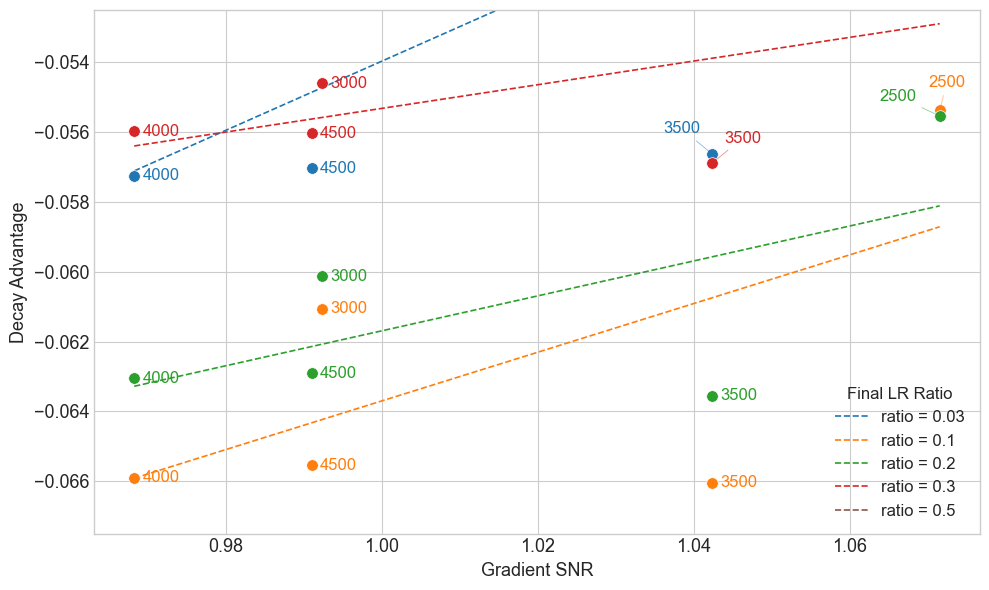

In [13]:
from scipy.stats import pearsonr

_sub = _adv.dropna(subset=["grad_snr", "decay_advantage"]).sort_values("probe_start_step")
_ratio_colors = dict(zip(sorted(_sub["final_lr_ratio"].unique()), plt.cm.tab10(np.linspace(0, 0.5, 5))))

_custom_offsets = {
    (0.3,  3500): ( 22,  18),
    (0.03, 3500): (-22,  18),
    (0.2,  2500): (-30,  14),
    (0.1,  2500): (  5,  20),
}

fig, ax = plt.subplots(figsize=(10, 6))

for ratio, group in _sub.groupby("final_lr_ratio"):
    x, y = group["grad_snr"].values, group["decay_advantage"].values
    color = _ratio_colors[ratio]
    ax.scatter(x, y, color=color, s=70, zorder=3, edgecolors="white", linewidths=0.5)
    for xi, yi, si in zip(x, y, group["probe_start_step"]):
        key = (ratio, si)
        if key in _custom_offsets:
            dx, dy = _custom_offsets[key]
            ax.annotate(f"{int(si)}", (xi, yi),
                        textcoords="offset points", xytext=(dx, dy),
                        fontsize=12, ha="center", va="center", color=color,
                        arrowprops=dict(arrowstyle="-", color=color, lw=0.6, alpha=0.5))
        else:
            ax.annotate(f"{int(si)}", (xi, yi),
                        textcoords="offset points", xytext=(6, 0),
                        fontsize=12, va="center", color=color)
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m * xs + b, color=color, linewidth=1.2, linestyle="--", label=f"ratio = {ratio:g}")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_ylim(-0.0675, -0.0525)
ax.set_xlabel("Gradient SNR", fontsize=13)
ax.set_ylabel("Decay Advantage", fontsize=13)
ax.legend(title="Final LR Ratio", fontsize=12, title_fontsize=12)
ax.tick_params(labelsize=13)
plt.tight_layout()
plt.show()

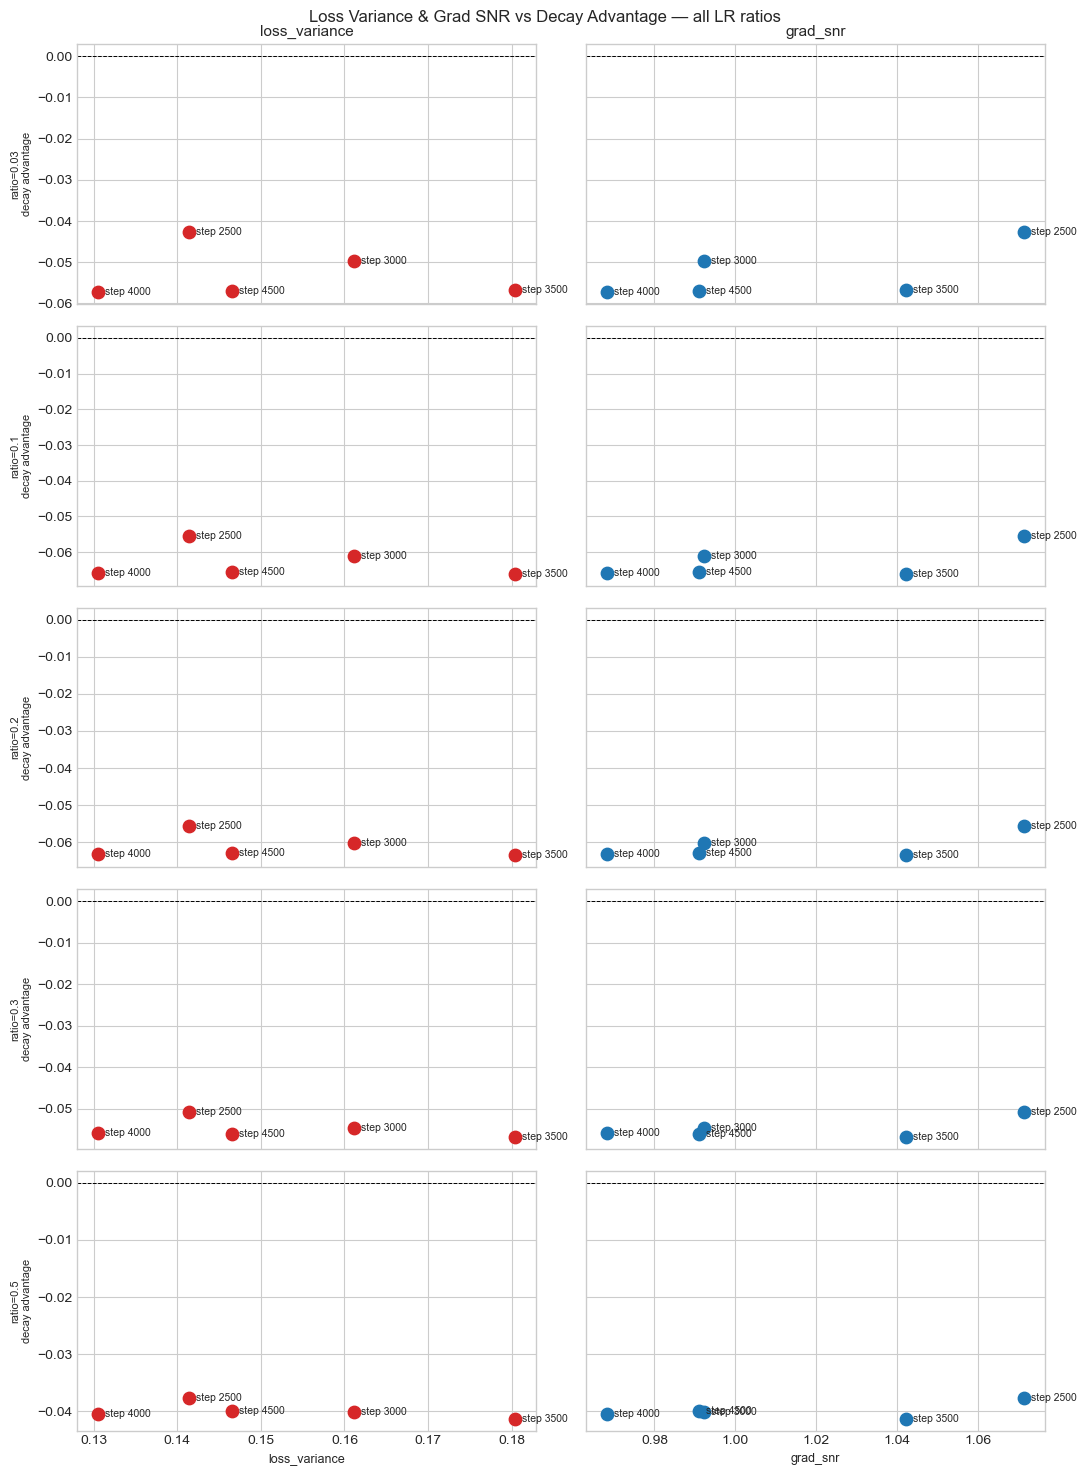

In [14]:
_lr_ratios = sorted(_adv["final_lr_ratio"].unique())

fig, axes = plt.subplots(len(_lr_ratios), 2, figsize=(11, 3 * len(_lr_ratios)),
                         sharey="row", sharex="col")

for row_idx, ratio in enumerate(_lr_ratios):
    sub = _adv[_adv["final_lr_ratio"] == ratio].sort_values("probe_start_step")
    for col_idx, (metric, color) in enumerate(zip(["loss_variance", "grad_snr"], ["tab:red", "tab:blue"])):
        ax = axes[row_idx, col_idx]
        for _, r in sub.iterrows():
            ax.scatter(r[metric], r["decay_advantage"], color=color, s=80, zorder=3)
            ax.annotate(f"step {int(r['probe_start_step'])}", (r[metric], r["decay_advantage"]),
                        textcoords="offset points", xytext=(5, 0), fontsize=7.5, va="center")
        ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
        if row_idx == 0:
            ax.set_title(metric, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"ratio={ratio:g}\ndecay advantage", fontsize=8)
        if row_idx == len(_lr_ratios) - 1:
            ax.set_xlabel(metric, fontsize=9)

fig.suptitle("Loss Variance & Grad SNR vs Decay Advantage — all LR ratios", fontsize=12)
plt.tight_layout()
plt.show()